Loading and preparing data...
Found 15 batches: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Total data points - O: 300, OH: 300
Train set sizes - O: 225, OH: 225
Test set sizes - O: 75, OH: 75
Training 8 models: GPR, LR, KNR, SVR, RFR, GBR, ABR, BAGR

Training GPR...
  O Model - MAE: 0.4384, RMSE: 0.5784, R²: 0.9910
  OH Model - MAE: 0.5187, RMSE: 0.6940, R²: 0.9870

Training LR...
  O Model - MAE: 0.4720, RMSE: 0.6115, R²: 0.9899
  OH Model - MAE: 0.5431, RMSE: 0.7197, R²: 0.9860

Training KNR...
  O Model - MAE: 1.0505, RMSE: 1.6207, R²: 0.9294
  OH Model - MAE: 1.1413, RMSE: 1.7043, R²: 0.9213

Training SVR...
  O Model - MAE: 1.0317, RMSE: 1.5804, R²: 0.9328
  OH Model - MAE: 1.0619, RMSE: 1.5740, R²: 0.9329

Training RFR...
  O Model - MAE: 1.2783, RMSE: 1.6102, R²: 0.9303
  OH Model - MAE: 1.2853, RMSE: 1.6187, R²: 0.9291

Training GBR...
  O Model - MAE: 0.7173, RMSE: 0.9619, R²: 0.9751
  OH Model - MAE: 0.7237, RMSE: 0.9274, R²: 0.9767

Training ABR...
  O Model - MAE: 

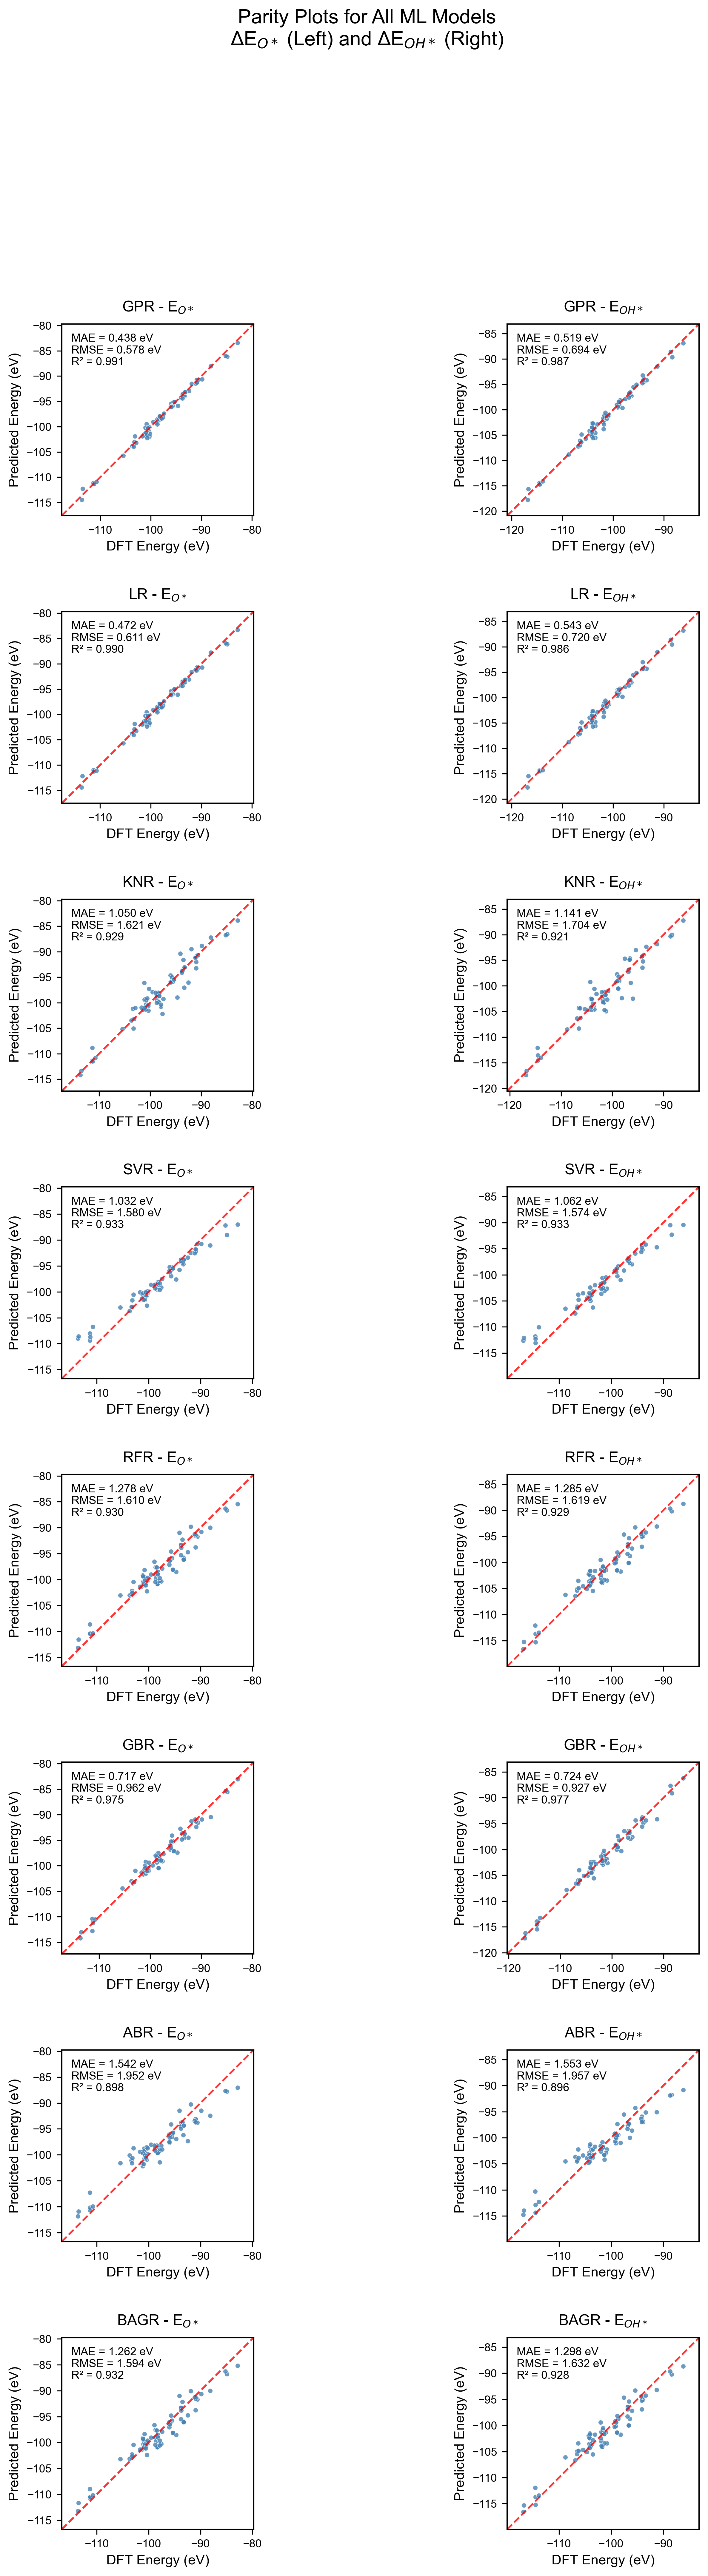

In [1]:
import sys
import os
from scipy.stats import norm
import csv
import numpy as np
from sklearn.model_selection import train_test_split
import sklearn.gaussian_process as gp
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import math
import pandas as pd
from pandas import DataFrame
from sklearn.gaussian_process.kernels import *
from scipy.spatial.distance import pdist, cdist, squareform
import bisect
import time

# Import additional models
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, BaggingRegressor
from sklearn.preprocessing import StandardScaler

# Import plotting libraries
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from matplotlib.gridspec import GridSpec

import warnings
warnings.filterwarnings('ignore')

# Font configuration
font_path = '/nas/minhee2043/font/'
for font in fm.findSystemFonts(font_path):
    fm.fontManager.addfont(font)

# Plot configuration
config = {
    'font.family': 'Arial',
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.titlepad': 8,
    'axes.linewidth': 1.0,
    'axes.labelsize': 11,
    'figure.figsize': (15, 20),  # Large figure to accommodate all subplots
    'legend.frameon': False,
    'legend.fontsize': 9,
    'lines.linewidth': 1.0,
    'lines.markersize': 3,
    'xtick.major.size': 4,
    'xtick.major.pad': 4,
    'xtick.labelsize': 9,
    'ytick.major.size': 4,
    'ytick.major.pad': 4,
    'ytick.labelsize': 9,
    'figure.dpi': 300,
}

plt.rcParams.update(config)

def _check_length_scale(X, length_scale):
    length_scale = np.squeeze(length_scale).astype(float)
    if np.ndim(length_scale) > 1:
        raise ValueError("length_scale cannot be of dimension greater than 1")
    if np.ndim(length_scale) == 1 and X.shape[1] != length_scale.shape[0]:
        raise ValueError(
            "Anisotropic kernel must have the same number of "
            "dimensions as data (%d!=%d)" % (length_scale.shape[0], X.shape[1])
        )
    return length_scale

class RBF_int(StationaryKernelMixin, NormalizedKernelMixin, Kernel):
    def __init__(self, length_scale=1.0, length_scale_bounds=(1e-5, 1e5)):
        self.length_scale = length_scale
        self.length_scale_bounds = length_scale_bounds

    @property
    def anisotropic(self):
        return np.iterable(self.length_scale) and len(self.length_scale) > 1

    @property
    def hyperparameter_length_scale(self):
        if self.anisotropic:
            return Hyperparameter(
                "length_scale",
                "numeric",
                self.length_scale_bounds,
                len(self.length_scale),
            )
        return Hyperparameter("length_scale", "numeric", self.length_scale_bounds)

    def __call__(self, X, Y=None, eval_gradient=False):
        X = np.atleast_2d(X)
        Xfilter = np.around(X)
        X = Xfilter
        length_scale = _check_length_scale(X, self.length_scale)
        if Y is None:
            dists = pdist(X / length_scale, metric="sqeuclidean")
            K = np.exp(-0.5 * dists)
            K = squareform(K)
            np.fill_diagonal(K, 1)
        else:
            if eval_gradient:
                raise ValueError("Gradient can only be evaluated when Y is None.")
            dists = cdist(X / length_scale, Y / length_scale, metric="sqeuclidean")
            K = np.exp(-0.5 * dists)

        if eval_gradient:
            if self.hyperparameter_length_scale.fixed:
                return K, np.empty((X.shape[0], X.shape[0], 0))
            elif not self.anisotropic or length_scale.shape[0] == 1:
                K_gradient = (K * squareform(dists))[:, :, np.newaxis]
                return K, K_gradient
            elif self.anisotropic:
                K_gradient = (X[:, np.newaxis, :] - X[np.newaxis, :, :]) ** 2 / (
                    length_scale ** 2
                )
                K_gradient *= K[..., np.newaxis]
                return K, K_gradient
        else:
            return K

    def __repr__(self):
        if self.anisotropic:
            return "{0}(length_scale=[{1}])".format(
                self.__class__.__name__,
                ", ".join(map("{0:.3g}".format, self.length_scale)),
            )
        else:
            return "{0}(length_scale={1:.3g})".format(
                self.__class__.__name__, np.ravel(self.length_scale)[0])

def load_data(filename):
    """Load data from CSV file"""
    x_all, y_all = [], []
    filepath = os.path.join('/nas_3/active/minhee2043/NiCoFe/1.MAE_plot/csv/total', filename)
    try:
        with open(filepath, 'r') as handle:
            for line in handle.readlines():
                parts = line.strip().split(',')
                if len(parts) >= 16:
                    features = parts[:15]
                    energy = float(parts[15])
                    x_all.append(features)
                    y_all.append(energy)
        x_all = np.array(x_all, dtype=int)
        y_all = np.array(y_all)
        return x_all, y_all
    except FileNotFoundError:
        print(f"Warning: {filepath} not found. Skipping...")
        return None, None

def create_models():
    """Create dictionary of models to compare"""
    models = {
        'GPR': lambda: gp.GaussianProcessRegressor(
            kernel=gp.kernels.ConstantKernel(1, (1e-1, 1e3)) * RBF_int(
                length_scale=0.2*np.ones((15,)), 
                length_scale_bounds=(1.0e-1, 1.0e3)
            ),
            n_restarts_optimizer=10, 
            alpha=0.05, 
            normalize_y=True
        ),
        'LR': lambda: LinearRegression(),
        'KNR': lambda: KNeighborsRegressor(n_neighbors=5, weights='distance'),
        'SVR': lambda: SVR(kernel='rbf', C=1.0, gamma='scale', epsilon=0.1),
        'RFR': lambda: RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
        'GBR': lambda: GradientBoostingRegressor(n_estimators=100, random_state=42),
        'ABR': lambda: AdaBoostRegressor(n_estimators=100, random_state=42),
        'BAGR': lambda: BaggingRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    }
    return models

def train_model_with_scaling(model, X_train, y_train, X_test, model_name):
    """Train model with appropriate scaling"""
    # Models that typically benefit from scaling
    scale_models = ['SVR', 'KNR', 'LR']
    
    if model_name in scale_models:
        # Scale features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # Train model
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        # Train without scaling
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    return y_pred

def calculate_metrics(y_true, y_pred):
    """Calculate MAE, RMSE, and R²"""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred)**0.5
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

def create_parity_plot(ax, y_true, y_pred, title, mae, rmse, r2):
    """Create a single parity plot"""
    # Calculate plot limits
    min_val = min(np.min(y_true), np.min(y_pred))
    max_val = max(np.max(y_true), np.max(y_pred))
    
    # Add some padding
    padding = (max_val - min_val) * 0.1
    plot_min = min_val - padding
    plot_max = max_val + padding
    
    # Create scatter plot
    ax.scatter(y_true, y_pred, alpha=0.8, s=15, color='steelblue', edgecolors='white', linewidth=0.3)
    
    # Add perfect prediction line (y=x)
    ax.plot([plot_min, plot_max], [plot_min, plot_max], 'r--', linewidth=1.5, alpha=0.8, label='Perfect Prediction')
    
    # Set equal aspect ratio and limits
    ax.set_xlim(plot_min, plot_max)
    ax.set_ylim(plot_min, plot_max)
    ax.set_aspect('equal')
    
    # Labels and title
    ax.set_xlabel('DFT Energy (eV)')
    ax.set_ylabel('Predicted Energy (eV)')
    ax.set_title(title, pad=10)
    
    # Add metrics text (without box)
    metrics_text = f'MAE = {mae:.3f} eV\nRMSE = {rmse:.3f} eV\nR² = {r2:.3f}'
    ax.text(0.05, 0.95, metrics_text, transform=ax.transAxes, 
            verticalalignment='top', fontsize=9)

def main():
    print("Loading and preparing data...")
    
    # Load all available data
    all_X_O, all_y_O = [], []
    all_X_OH, all_y_OH = [], []
    
    # Load all available batches
    available_batches = []
    for i in range(1, 16):
        X_O, y_O = load_data(f'DFT_O_batch{i}.csv')
        X_OH, y_OH = load_data(f'DFT_OH_batch{i}.csv')
        
        if X_O is not None and X_OH is not None:
            all_X_O.append(X_O)
            all_y_O.append(y_O)
            all_X_OH.append(X_OH)
            all_y_OH.append(y_OH)
            available_batches.append(i)
    
    if not available_batches:
        print("No data files found!")
        return
    
    print(f"Found {len(available_batches)} batches: {available_batches}")
    
    # Combine all data
    X_O_all = np.vstack(all_X_O)
    y_O_all = np.hstack(all_y_O)
    X_OH_all = np.vstack(all_X_OH)
    y_OH_all = np.hstack(all_y_OH)
    
    print(f"Total data points - O: {len(X_O_all)}, OH: {len(X_OH_all)}")
    
    # Create FIXED train/test split using the same random state for both O and OH
    test_size = 0.25
    
    # Split O data
    X_O_train, X_O_test, y_O_train, y_O_test = train_test_split(
        X_O_all, y_O_all, test_size=test_size, random_state=42
    )
    
    # Split OH data with same random state
    X_OH_train, X_OH_test, y_OH_train, y_OH_test = train_test_split(
        X_OH_all, y_OH_all, test_size=test_size, random_state=42
    )
    
    print(f"Train set sizes - O: {len(X_O_train)}, OH: {len(X_OH_train)}")
    print(f"Test set sizes - O: {len(X_O_test)}, OH: {len(X_OH_test)}")
    
    # Get models
    models = create_models()
    model_names = list(models.keys())
    n_models = len(model_names)
    
    print(f"Training {n_models} models: {', '.join(model_names)}")
    
    # Create figure with subplots (2 columns: O and OH, n_models rows)
    fig = plt.figure(figsize=(12, 4*n_models))
    gs = GridSpec(n_models, 2, figure=fig, hspace=0.5, wspace=0.15)
    
    # Store results for summary
    results_summary = []
    
    # Train each model and create parity plots
    for i, model_name in enumerate(model_names):
        print(f"\nTraining {model_name}...")
        
        # Train O model
        model_O = models[model_name]()
        y_pred_O = train_model_with_scaling(model_O, X_O_train, y_O_train, X_O_test, model_name)
        mae_O, rmse_O, r2_O = calculate_metrics(y_O_test, y_pred_O)
        
        # Train OH model
        model_OH = models[model_name]()
        y_pred_OH = train_model_with_scaling(model_OH, X_OH_train, y_OH_train, X_OH_test, model_name)
        mae_OH, rmse_OH, r2_OH = calculate_metrics(y_OH_test, y_pred_OH)
        
        # Store results
        results_summary.append({
            'Model': model_name,
            'MAE_O': mae_O,
            'RMSE_O': rmse_O,
            'R2_O': r2_O,
            'MAE_OH': mae_OH,
            'RMSE_OH': rmse_OH,
            'R2_OH': r2_OH
        })
        
        # Create parity plots
        # O plot (left column)
        ax_O = fig.add_subplot(gs[i, 0])
        create_parity_plot(ax_O, y_O_test, y_pred_O, f'{model_name} - E$_{{O*}}$', mae_O, rmse_O, r2_O)
        
        # OH plot (right column)
        ax_OH = fig.add_subplot(gs[i, 1])
        create_parity_plot(ax_OH, y_OH_test, y_pred_OH, f'{model_name} - E$_{{OH*}}$', mae_OH, rmse_OH, r2_OH)
        
        print(f"  O Model - MAE: {mae_O:.4f}, RMSE: {rmse_O:.4f}, R²: {r2_O:.4f}")
        print(f"  OH Model - MAE: {mae_OH:.4f}, RMSE: {rmse_OH:.4f}, R²: {r2_OH:.4f}")
    
    # Add main title
    fig.suptitle('Parity Plots for All ML Models\nΔE$_{O*}$ (Left) and ΔE$_{OH*}$ (Right)', 
                 fontsize=16, fontweight='bold', y=0.99)
    
    # Save the plot
    plt.savefig('ml_models_parity_plots.pdf', bbox_inches='tight', dpi=300)
    plt.savefig('ml_models_parity_plots.png', bbox_inches='tight', dpi=300)
    
    # Save results summary
    df_results = pd.DataFrame(results_summary)
    df_results.to_csv('ml_models_parity_results.csv', index=False)
    
    # Print summary table
    print(f"\n{'='*100}")
    print("PARITY PLOT RESULTS SUMMARY")
    print(f"{'='*100}")
    print(f"{'Model':<6} {'MAE_O':<8} {'RMSE_O':<8} {'R2_O':<8} {'MAE_OH':<8} {'RMSE_OH':<8} {'R2_OH':<8}")
    print("-"*80)
    
    for _, row in df_results.iterrows():
        print(f"{row['Model']:<6} {row['MAE_O']:<8.4f} {row['RMSE_O']:<8.4f} {row['R2_O']:<8.4f} "
              f"{row['MAE_OH']:<8.4f} {row['RMSE_OH']:<8.4f} {row['R2_OH']:<8.4f}")
    
    # Best models analysis
    best_O_mae = df_results.loc[df_results['MAE_O'].idxmin()]
    best_OH_mae = df_results.loc[df_results['MAE_OH'].idxmin()]
    best_O_r2 = df_results.loc[df_results['R2_O'].idxmax()]
    best_OH_r2 = df_results.loc[df_results['R2_OH'].idxmax()]
    
    print(f"\n{'='*60}")
    print("BEST PERFORMING MODELS")
    print(f"{'='*60}")
    print(f"Best O prediction (MAE): {best_O_mae['Model']} (MAE: {best_O_mae['MAE_O']:.4f})")
    print(f"Best OH prediction (MAE): {best_OH_mae['Model']} (MAE: {best_OH_mae['MAE_OH']:.4f})")
    print(f"Best O prediction (R²): {best_O_r2['Model']} (R²: {best_O_r2['R2_O']:.4f})")
    print(f"Best OH prediction (R²): {best_OH_r2['Model']} (R²: {best_OH_r2['R2_OH']:.4f})")
    
    print(f"\nFiles saved:")
    print("- ml_models_parity_plots.pdf")
    print("- ml_models_parity_plots.png") 
    print("- ml_models_parity_results.csv")
    
    plt.show()

if __name__ == "__main__":
    main()

Loading and preparing data...
Found 15 batches: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Total data points - O: 300, OH: 300, Diff: 254
Train set sizes - O: 225, OH: 225, Diff: 190
Test set sizes - O: 75, OH: 75, Diff: 64

Training GPR models...
Training E_O* model...
Training E_OH* model...
Training E_O* - E_OH* model...

E_O* Model - MAE: 0.4384, RMSE: 0.5784, R²: 0.9910
E_OH* Model - MAE: 0.5187, RMSE: 0.6940, R²: 0.9870
E_O*-E_OH* Model - MAE: 0.0168, RMSE: 0.0216, R²: 0.9774

Saving predictions to CSV files...

SUMMARY
Model           MAE (eV)     RMSE (eV)    R²          
--------------------------------------------------------------------------------
E_O*            0.4384       0.5784       0.9910      
E_OH*           0.5187       0.6940       0.9870      
E_O*-E_OH*      0.0168       0.0216       0.9774      

Files saved:
- gpr_three_parity_plots.png
- gpr_three_parity_plots.pdf
- predictions_E_O.csv
- predictions_E_OH.csv
- predictions_E_O_minus_E_OH.csv
- metric

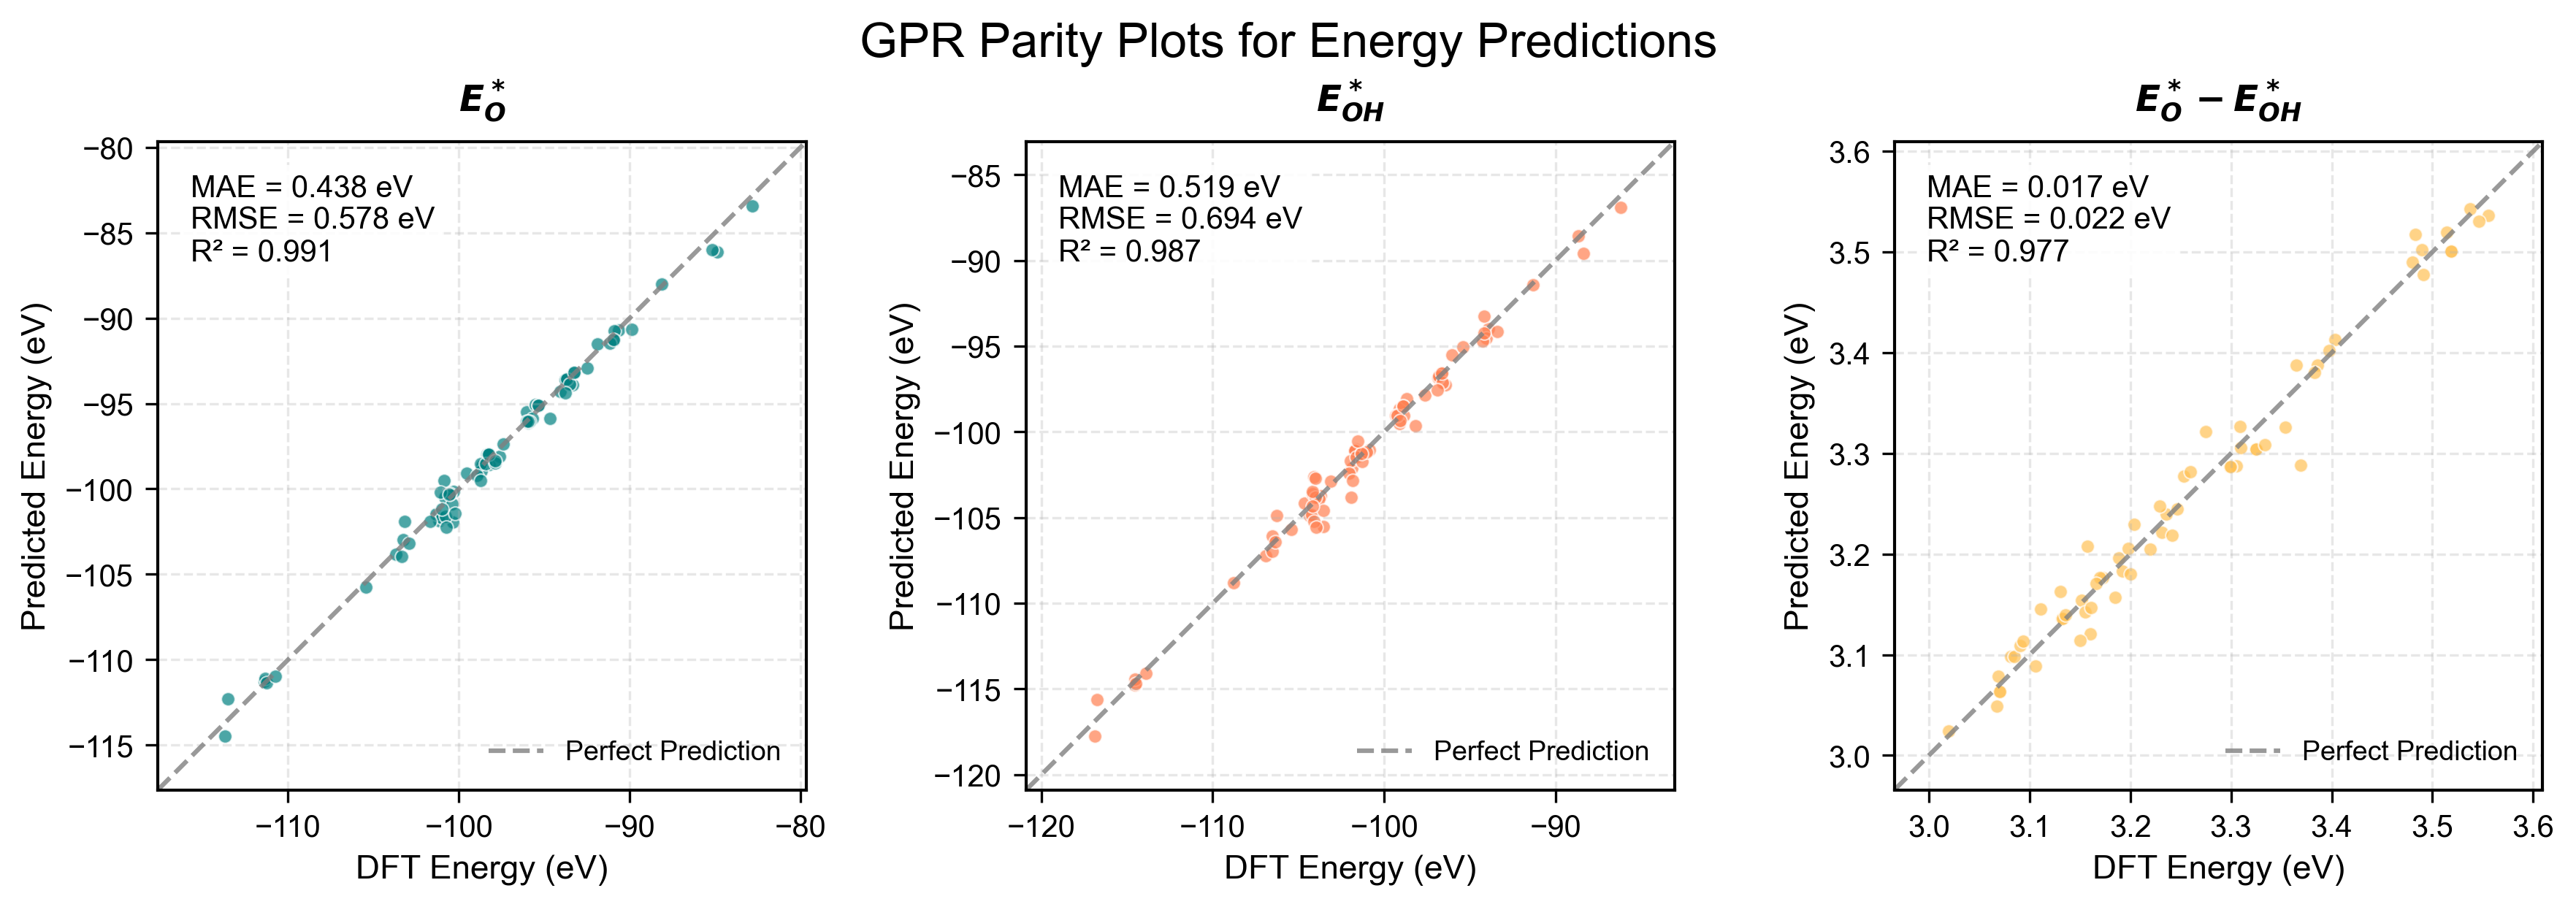

In [5]:
import sys
import os
from scipy.stats import norm
import csv
import numpy as np
from sklearn.model_selection import train_test_split
import sklearn.gaussian_process as gp
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import math
import pandas as pd
from pandas import DataFrame
from sklearn.gaussian_process.kernels import *
from scipy.spatial.distance import pdist, cdist, squareform
import bisect
import time

# Import plotting libraries
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.gridspec import GridSpec

import warnings
warnings.filterwarnings('ignore')

# Font configuration
font_path = '/nas/minhee2043/font/'
for font in fm.findSystemFonts(font_path):
    fm.fontManager.addfont(font)

# Plot configuration
config = {
    'font.family': 'Arial',
    'font.size': 10,
    'font.weight': 'bold',
    'axes.titlesize': 12,
    'axes.titlepad': 8,
    'axes.titleweight': 'bold',
    'axes.linewidth': 1.0,
    'axes.labelsize': 11,
    'axes.labelweight': 'bold',
    'legend.frameon': False,
    'legend.fontsize': 9,
    'lines.linewidth': 1.0,
    'lines.markersize': 3,
    'xtick.major.size': 4,
    'xtick.major.pad': 4,
    'xtick.labelsize': 10,
    'ytick.major.size': 4,
    'ytick.major.pad': 4,
    'ytick.labelsize': 10,
    'figure.dpi': 300,
}

plt.rcParams.update(config)

def _check_length_scale(X, length_scale):
    length_scale = np.squeeze(length_scale).astype(float)
    if np.ndim(length_scale) > 1:
        raise ValueError("length_scale cannot be of dimension greater than 1")
    if np.ndim(length_scale) == 1 and X.shape[1] != length_scale.shape[0]:
        raise ValueError(
            "Anisotropic kernel must have the same number of "
            "dimensions as data (%d!=%d)" % (length_scale.shape[0], X.shape[1])
        )
    return length_scale

class RBF_int(StationaryKernelMixin, NormalizedKernelMixin, Kernel):
    def __init__(self, length_scale=1.0, length_scale_bounds=(1e-5, 1e5)):
        self.length_scale = length_scale
        self.length_scale_bounds = length_scale_bounds

    @property
    def anisotropic(self):
        return np.iterable(self.length_scale) and len(self.length_scale) > 1

    @property
    def hyperparameter_length_scale(self):
        if self.anisotropic:
            return Hyperparameter(
                "length_scale",
                "numeric",
                self.length_scale_bounds,
                len(self.length_scale),
            )
        return Hyperparameter("length_scale", "numeric", self.length_scale_bounds)

    def __call__(self, X, Y=None, eval_gradient=False):
        X = np.atleast_2d(X)
        Xfilter = np.around(X)
        X = Xfilter
        length_scale = _check_length_scale(X, self.length_scale)
        if Y is None:
            dists = pdist(X / length_scale, metric="sqeuclidean")
            K = np.exp(-0.5 * dists)
            K = squareform(K)
            np.fill_diagonal(K, 1)
        else:
            if eval_gradient:
                raise ValueError("Gradient can only be evaluated when Y is None.")
            dists = cdist(X / length_scale, Y / length_scale, metric="sqeuclidean")
            K = np.exp(-0.5 * dists)

        if eval_gradient:
            if self.hyperparameter_length_scale.fixed:
                return K, np.empty((X.shape[0], X.shape[0], 0))
            elif not self.anisotropic or length_scale.shape[0] == 1:
                K_gradient = (K * squareform(dists))[:, :, np.newaxis]
                return K, K_gradient
            elif self.anisotropic:
                K_gradient = (X[:, np.newaxis, :] - X[np.newaxis, :, :]) ** 2 / (
                    length_scale ** 2
                )
                K_gradient *= K[..., np.newaxis]
                return K, K_gradient
        else:
            return K

    def __repr__(self):
        if self.anisotropic:
            return "{0}(length_scale=[{1}])".format(
                self.__class__.__name__,
                ", ".join(map("{0:.3g}".format, self.length_scale)),
            )
        else:
            return "{0}(length_scale={1:.3g})".format(
                self.__class__.__name__, np.ravel(self.length_scale)[0])

def load_data(filename):
    """Load data from CSV file"""
    x_all, y_all = [], []
    filepath = os.path.join('/nas_3/active/minhee2043/NiCoFe/1.MAE_plot/csv/total', filename)
    try:
        with open(filepath, 'r') as handle:
            for line in handle.readlines():
                parts = line.strip().split(',')
                if len(parts) >= 16:
                    features = parts[:15]
                    energy = float(parts[15])
                    x_all.append(features)
                    y_all.append(energy)
        x_all = np.array(x_all, dtype=int)
        y_all = np.array(y_all)
        return x_all, y_all
    except FileNotFoundError:
        print(f"Warning: {filepath} not found. Skipping...")
        return None, None

def calculate_metrics(y_true, y_pred):
    """Calculate MAE, RMSE, and R²"""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred)**0.5
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

def create_parity_plot(ax, y_true, y_pred, title, mae, rmse, r2, color='steelblue'):
    """Create a single parity plot"""
    # Calculate plot limits
    min_val = min(np.min(y_true), np.min(y_pred))
    max_val = max(np.max(y_true), np.max(y_pred))
    
    # Add some padding
    padding = (max_val - min_val) * 0.1
    plot_min = min_val - padding
    plot_max = max_val + padding
    
    # Create scatter plot
    ax.scatter(y_true, y_pred, alpha=0.7, s=20, color=color, edgecolors='white', linewidth=0.5)
    
    # Add perfect prediction line (y=x)
    ax.plot([plot_min, plot_max], [plot_min, plot_max], '--', color='gray', linewidth=1.5, alpha=0.8, label='Perfect Prediction')
    
    # Set equal aspect ratio and limits
    ax.set_xlim(plot_min, plot_max)
    ax.set_ylim(plot_min, plot_max)
    ax.set_aspect('equal')
    
    # Labels and title - BOLD
    ax.set_xlabel('DFT Energy (eV)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Predicted Energy (eV)', fontsize=11, fontweight='bold')
    ax.set_title(title, pad=10, fontsize=12, fontweight='bold')
    
    # Add metrics text - NO BORDER, bold text
    metrics_text = f'MAE = {mae:.3f} eV\nRMSE = {rmse:.3f} eV\nR² = {r2:.3f}'
    ax.text(0.05, 0.95, metrics_text, transform=ax.transAxes, 
            verticalalignment='top', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, 
                     edgecolor='none'))
    
    # Add grid
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Add legend with bold text
    legend = ax.legend(loc='lower right', frameon=False, fontsize=9)
    for text in legend.get_texts():
        text.set_fontweight('bold')
    
    # Make tick labels bold - THIS IS CRITICAL
    ax.tick_params(axis='both', which='major', labelsize=10)
    for label in ax.get_xticklabels():
        label.set_fontweight('bold')
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')

def main():
    print("Loading and preparing data...")
    
    # Load all available data
    all_X_O, all_y_O = [], []
    all_X_OH, all_y_OH = [], []
    all_X_diff, all_y_diff = [], []
    
    # Load all available batches
    available_batches = []
    for i in range(1, 16):
        X_O, y_O = load_data(f'DFT_O_batch{i}.csv')
        X_OH, y_OH = load_data(f'DFT_OH_batch{i}.csv')
        X_diff, y_diff = load_data(f'difference_optimal_batch{i}.csv')
        
        if X_O is not None and X_OH is not None and X_diff is not None:
            all_X_O.append(X_O)
            all_y_O.append(y_O)
            all_X_OH.append(X_OH)
            all_y_OH.append(y_OH)
            all_X_diff.append(X_diff)
            all_y_diff.append(y_diff)
            available_batches.append(i)
    
    if not available_batches:
        print("No data files found!")
        return
    
    print(f"Found {len(available_batches)} batches: {available_batches}")
    
    # Combine all data
    X_O_all = np.vstack(all_X_O)
    y_O_all = np.hstack(all_y_O)
    X_OH_all = np.vstack(all_X_OH)
    y_OH_all = np.hstack(all_y_OH)
    X_diff_all = np.vstack(all_X_diff)
    y_diff_all = np.hstack(all_y_diff)
    
    print(f"Total data points - O: {len(X_O_all)}, OH: {len(X_OH_all)}, Diff: {len(X_diff_all)}")
    
    # Create FIXED train/test split using the same random state for all datasets
    test_size = 0.25
    
    # Split O data
    X_O_train, X_O_test, y_O_train, y_O_test = train_test_split(
        X_O_all, y_O_all, test_size=test_size, random_state=42
    )
    
    # Split OH data with same random state
    X_OH_train, X_OH_test, y_OH_train, y_OH_test = train_test_split(
        X_OH_all, y_OH_all, test_size=test_size, random_state=42
    )
    
    # Split difference data with same random state
    X_diff_train, X_diff_test, y_diff_train, y_diff_test = train_test_split(
        X_diff_all, y_diff_all, test_size=test_size, random_state=42
    )
    
    print(f"Train set sizes - O: {len(X_O_train)}, OH: {len(X_OH_train)}, Diff: {len(X_diff_train)}")
    print(f"Test set sizes - O: {len(X_O_test)}, OH: {len(X_OH_test)}, Diff: {len(X_diff_test)}")
    
    # Train GPR models
    print("\nTraining GPR models...")
    
    # Train O model
    print("Training E_O* model...")
    model_O = gp.GaussianProcessRegressor(
        kernel=gp.kernels.ConstantKernel(1, (1e-1, 1e3)) * RBF_int(
            length_scale=0.2*np.ones((15,)), 
            length_scale_bounds=(1.0e-1, 1.0e3)
        ),
        n_restarts_optimizer=10, 
        alpha=0.05, 
        normalize_y=True
    )
    model_O.fit(X_O_train, y_O_train)
    y_pred_O = model_O.predict(X_O_test)
    mae_O, rmse_O, r2_O = calculate_metrics(y_O_test, y_pred_O)
    
    # Train OH model
    print("Training E_OH* model...")
    model_OH = gp.GaussianProcessRegressor(
        kernel=gp.kernels.ConstantKernel(1, (1e-1, 1e3)) * RBF_int(
            length_scale=0.2*np.ones((15,)), 
            length_scale_bounds=(1.0e-1, 1.0e3)
        ),
        n_restarts_optimizer=10, 
        alpha=0.05, 
        normalize_y=True
    )
    model_OH.fit(X_OH_train, y_OH_train)
    y_pred_OH = model_OH.predict(X_OH_test)
    mae_OH, rmse_OH, r2_OH = calculate_metrics(y_OH_test, y_pred_OH)
    
    # Train difference model (E_O - E_OH)
    print("Training E_O* - E_OH* model...")
    model_diff = gp.GaussianProcessRegressor(
        kernel=gp.kernels.ConstantKernel(1, (1e-1, 1e3)) * RBF_int(
            length_scale=0.2*np.ones((15,)), 
            length_scale_bounds=(1.0e-1, 1.0e3)
        ),
        n_restarts_optimizer=10, 
        alpha=0.05, 
        normalize_y=True
    )
    model_diff.fit(X_diff_train, y_diff_train)
    y_pred_diff = model_diff.predict(X_diff_test)
    mae_diff, rmse_diff, r2_diff = calculate_metrics(y_diff_test, y_pred_diff)
    
    print(f"\nE_O* Model - MAE: {mae_O:.4f}, RMSE: {rmse_O:.4f}, R²: {r2_O:.4f}")
    print(f"E_OH* Model - MAE: {mae_OH:.4f}, RMSE: {rmse_OH:.4f}, R²: {r2_OH:.4f}")
    print(f"E_O*-E_OH* Model - MAE: {mae_diff:.4f}, RMSE: {rmse_diff:.4f}, R²: {r2_diff:.4f}")
    
    # Create figure with 3 subplots
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    fig.suptitle('GPR Parity Plots for Energy Predictions', fontsize=16, fontweight='bold')
    
    # Color scheme
    colors = ['#008080', '#FF7F50', '#FFC154']  # teal, coral, yellow
    
    # Plot 1: E_O*
    create_parity_plot(axes[0], y_O_test, y_pred_O, 
                      r'$E_O^*$', mae_O, rmse_O, r2_O, color=colors[0])
    
    # Plot 2: E_OH*
    create_parity_plot(axes[1], y_OH_test, y_pred_OH, 
                      r'$E_{OH}^*$', mae_OH, rmse_OH, r2_OH, color=colors[1])
    
    # Plot 3: E_O* - E_OH* (using actual difference data)
    create_parity_plot(axes[2], y_diff_test, y_pred_diff, 
                      r'$E_O^* - E_{OH}^*$', mae_diff, rmse_diff, r2_diff, color=colors[2])
    
    # Force tick labels to be bold for all subplots
    for ax in axes:
        for label in ax.get_xticklabels():
            label.set_fontweight('bold')
        for label in ax.get_yticklabels():
            label.set_fontweight('bold')
    
    plt.tight_layout()
    plt.savefig('gpr_three_parity_plots.png', dpi=300, bbox_inches='tight')
    plt.savefig('gpr_three_parity_plots.pdf', dpi=300, bbox_inches='tight')
    
    # Save predictions to CSV files
    print("\nSaving predictions to CSV files...")
    
    # Save E_O* predictions
    df_O = pd.DataFrame({
        'DFT_E_O': y_O_test,
        'Predicted_E_O': y_pred_O,
        'Error': y_pred_O - y_O_test,
        'Absolute_Error': np.abs(y_pred_O - y_O_test)
    })
    df_O.to_csv('predictions_E_O.csv', index=False)
    
    # Save E_OH* predictions
    df_OH = pd.DataFrame({
        'DFT_E_OH': y_OH_test,
        'Predicted_E_OH': y_pred_OH,
        'Error': y_pred_OH - y_OH_test,
        'Absolute_Error': np.abs(y_pred_OH - y_OH_test)
    })
    df_OH.to_csv('predictions_E_OH.csv', index=False)
    
    # Save E_O* - E_OH* predictions (using actual difference data)
    df_diff = pd.DataFrame({
        'DFT_Difference': y_diff_test,
        'Predicted_Difference': y_pred_diff,
        'Error': y_pred_diff - y_diff_test,
        'Absolute_Error': np.abs(y_pred_diff - y_diff_test)
    })
    df_diff.to_csv('predictions_E_O_minus_E_OH.csv', index=False)
    
    # Save summary metrics
    df_metrics = pd.DataFrame({
        'Model': ['E_O*', 'E_OH*', 'E_O*-E_OH*'],
        'MAE': [mae_O, mae_OH, mae_diff],
        'RMSE': [rmse_O, rmse_OH, rmse_diff],
        'R2': [r2_O, r2_OH, r2_diff]
    })
    df_metrics.to_csv('metrics_summary.csv', index=False)
    
    print("\n" + "="*80)
    print("SUMMARY")
    print("="*80)
    print(f"{'Model':<15} {'MAE (eV)':<12} {'RMSE (eV)':<12} {'R²':<12}")
    print("-"*80)
    print(f"{'E_O*':<15} {mae_O:<12.4f} {rmse_O:<12.4f} {r2_O:<12.4f}")
    print(f"{'E_OH*':<15} {mae_OH:<12.4f} {rmse_OH:<12.4f} {r2_OH:<12.4f}")
    print(f"{'E_O*-E_OH*':<15} {mae_diff:<12.4f} {rmse_diff:<12.4f} {r2_diff:<12.4f}")
    
    print("\nFiles saved:")
    print("- gpr_three_parity_plots.png")
    print("- gpr_three_parity_plots.pdf")
    print("- predictions_E_O.csv")
    print("- predictions_E_OH.csv")
    print("- predictions_E_O_minus_E_OH.csv")
    print("- metrics_summary.csv")
    
    plt.show()

if __name__ == "__main__":
    main()

Bar plot saved as:
- ml_models_bar_comparison.png
- ml_models_bar_comparison.pdf

MODEL PERFORMANCE SUMMARY

Best E_O* Models:
  Lowest MAE: GPR (0.4384 eV)
  Lowest RMSE: GPR (0.5784 eV)
  Highest R²: GPR (0.9910)

Best E_OH* Models:
  Lowest MAE: GPR (0.5187 eV)
  Lowest RMSE: GPR (0.6940 eV)
  Highest R²: GPR (0.9870)


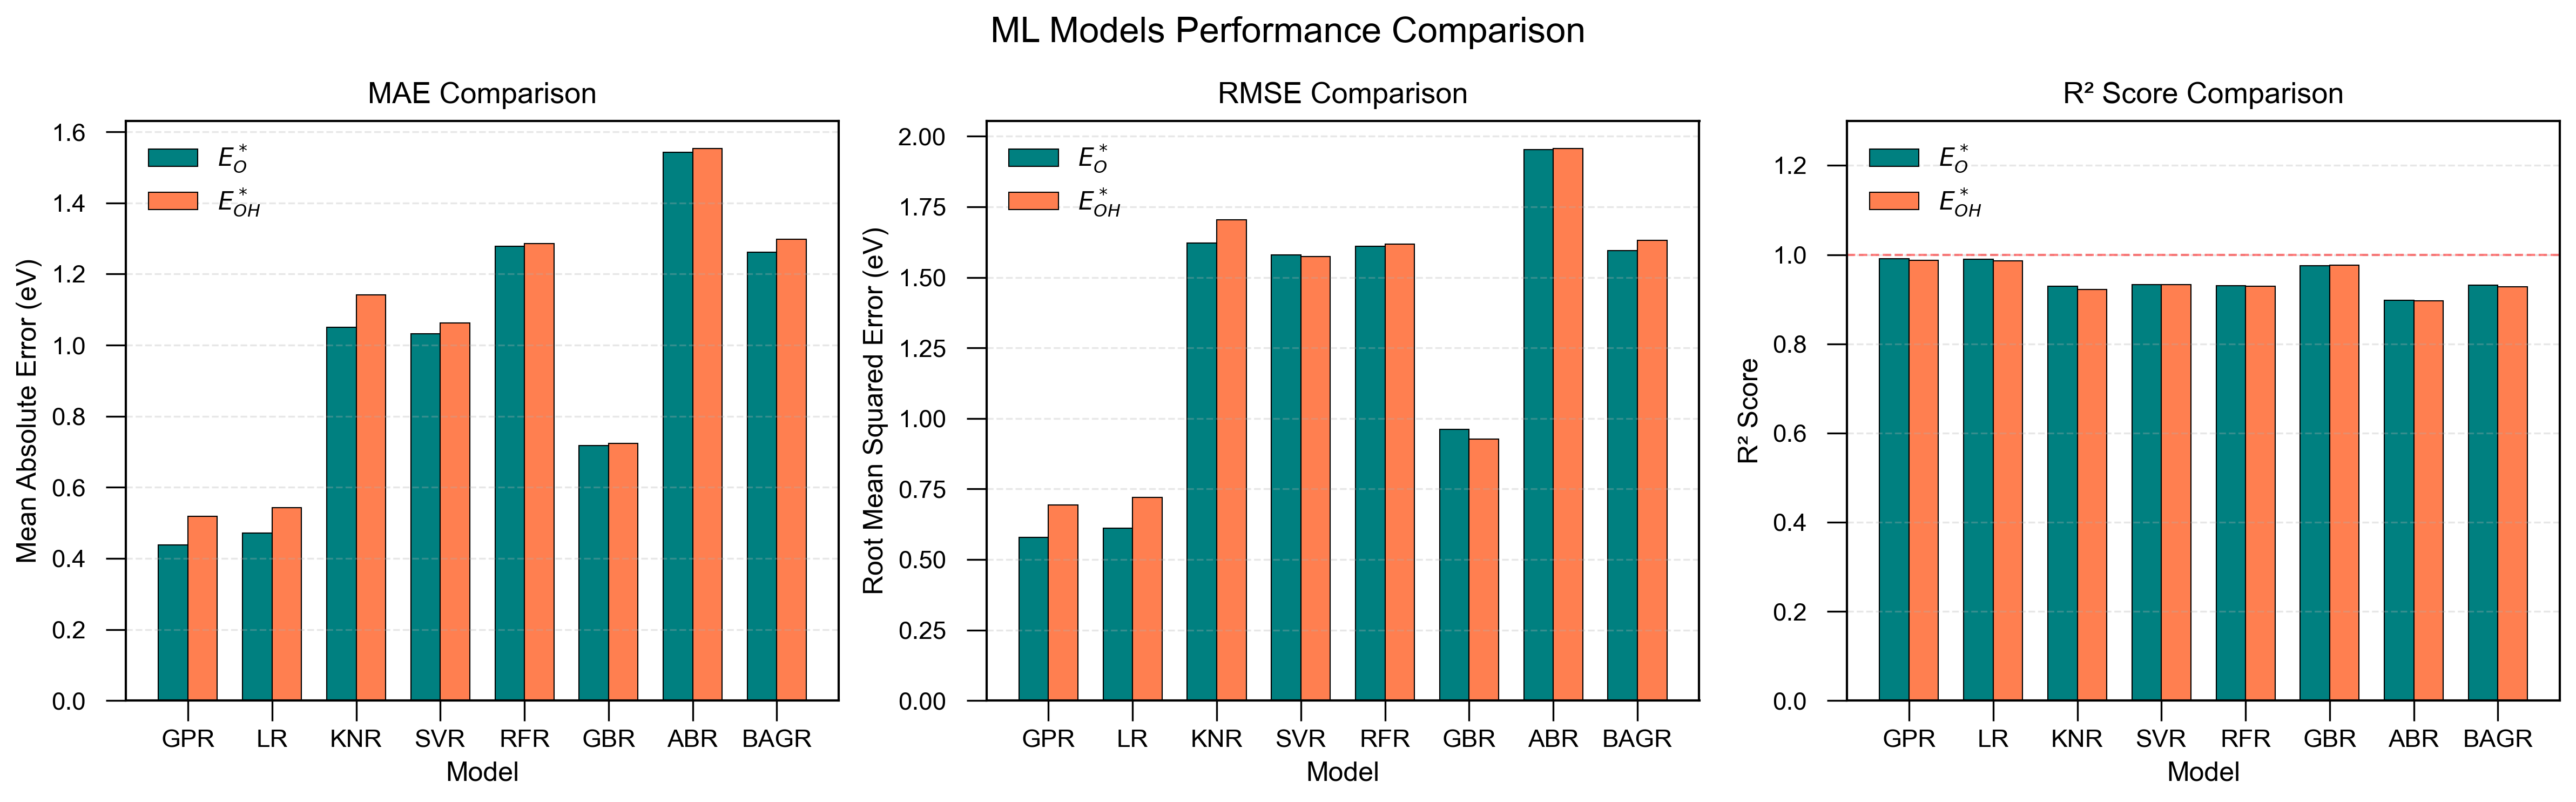

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# Font configuration
font_path = '/data2/minhee2043/font/'
for font in fm.findSystemFonts(font_path):
    fm.fontManager.addfont(font)

# Plot configuration
config = {
    'font.family': 'Arial',
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.titlepad': 8,
    'axes.linewidth': 1.0,
    'axes.labelsize': 11,
    'legend.frameon': False,
    'legend.fontsize': 9,
    'lines.linewidth': 1.0,
    'lines.markersize': 3,
    'xtick.major.size': 9,
    'xtick.labelsize': 11,
    'ytick.major.size': 9,
    'ytick.major.pad': 9,
    'ytick.labelsize': 11,
    'figure.dpi': 300,
}

plt.rcParams.update(config)

# Read the results CSV file
df = pd.read_csv('ml_models_parity_results.csv')

# Model names
models = df['Model'].values
n_models = len(models)

# Set up bar positions
x = np.arange(n_models)
width = 0.35  # Width of bars

# Create figure with 3 subplots (MAE, RMSE, R²)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('ML Models Performance Comparison', fontsize=16, fontweight='bold')

# Color scheme
color_O = '#008080'    # teal for O
color_OH = '#FF7F50'   # gray for OH

# Plot 1: MAE comparison
ax1 = axes[0]
bars1 = ax1.bar(x - width/2, df['MAE_O'], width, label=r'$E_O^*$', 
                color=color_O, edgecolor='black', linewidth=0.5)
bars2 = ax1.bar(x + width/2, df['MAE_OH'], width, label=r'$E_{OH}^*$', 
                color=color_OH, edgecolor='black', linewidth=0.5)

ax1.set_xlabel('Model', fontsize=12, fontweight='bold')
ax1.set_ylabel('Mean Absolute Error (eV)', fontsize=12, fontweight='bold')
ax1.set_title('MAE Comparison', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=0, ha='center')
ax1.legend(loc='upper left', fontsize=11)
ax1.grid(True, alpha=0.3, linestyle='--', axis='y')

# Plot 2: RMSE comparison
ax2 = axes[1]
bars3 = ax2.bar(x - width/2, df['RMSE_O'], width, label=r'$E_O^*$', 
                color=color_O, edgecolor='black', linewidth=0.5)
bars4 = ax2.bar(x + width/2, df['RMSE_OH'], width, label=r'$E_{OH}^*$', 
                color=color_OH, edgecolor='black', linewidth=0.5)

ax2.set_xlabel('Model', fontsize=12, fontweight='bold')
ax2.set_ylabel('Root Mean Squared Error (eV)', fontsize=12, fontweight='bold')
ax2.set_title('RMSE Comparison', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(models, rotation=0, ha='center')
ax2.legend(loc='upper left', fontsize=11)
ax2.grid(True, alpha=0.3, linestyle='--', axis='y')

# Plot 3: R² comparison
ax3 = axes[2]
bars5 = ax3.bar(x - width/2, df['R2_O'], width, label=r'$E_O^*$', 
                color=color_O, edgecolor='black', linewidth=0.5)
bars6 = ax3.bar(x + width/2, df['R2_OH'], width, label=r'$E_{OH}^*$', 
                color=color_OH, edgecolor='black', linewidth=0.5)

ax3.set_xlabel('Model', fontsize=12, fontweight='bold')
ax3.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax3.set_title('R² Score Comparison', fontsize=13, fontweight='bold')
ax3.set_xticks(x)
ax3.set_ylim(0, 1.3)
ax3.set_xticklabels(models, rotation=0, ha='center')
ax3.legend(loc='upper left', fontsize=11)
ax3.grid(True, alpha=0.3, linestyle='--', axis='y')
ax3.axhline(y=1.0, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Perfect R²')

plt.tight_layout()
plt.savefig('ml_models_bar_comparison.png', dpi=300, bbox_inches='tight')
plt.savefig('ml_models_bar_comparison.pdf', dpi=300, bbox_inches='tight')

print("Bar plot saved as:")
print("- ml_models_bar_comparison.png")
print("- ml_models_bar_comparison.pdf")

# Print summary statistics
print("\n" + "="*80)
print("MODEL PERFORMANCE SUMMARY")
print("="*80)

# Best models for each metric
best_mae_O = df.loc[df['MAE_O'].idxmin()]
best_mae_OH = df.loc[df['MAE_OH'].idxmin()]
best_rmse_O = df.loc[df['RMSE_O'].idxmin()]
best_rmse_OH = df.loc[df['RMSE_OH'].idxmin()]
best_r2_O = df.loc[df['R2_O'].idxmax()]
best_r2_OH = df.loc[df['R2_OH'].idxmax()]

print(f"\nBest E_O* Models:")
print(f"  Lowest MAE: {best_mae_O['Model']} ({best_mae_O['MAE_O']:.4f} eV)")
print(f"  Lowest RMSE: {best_rmse_O['Model']} ({best_rmse_O['RMSE_O']:.4f} eV)")
print(f"  Highest R²: {best_r2_O['Model']} ({best_r2_O['R2_O']:.4f})")

print(f"\nBest E_OH* Models:")
print(f"  Lowest MAE: {best_mae_OH['Model']} ({best_mae_OH['MAE_OH']:.4f} eV)")
print(f"  Lowest RMSE: {best_rmse_OH['Model']} ({best_rmse_OH['RMSE_OH']:.4f} eV)")
print(f"  Highest R²: {best_r2_OH['Model']} ({best_r2_OH['R2_OH']:.4f})")

plt.show()

Plot saved as 'mae_rmse_evolution.png'

Dataset summary:
Total iterations: 15
Training samples: 18 → 225
MAE O improvement: 4.508 → 0.656
MAE OH improvement: 2.799 → 0.519
MAE Target improvement: 5.048 → 0.760


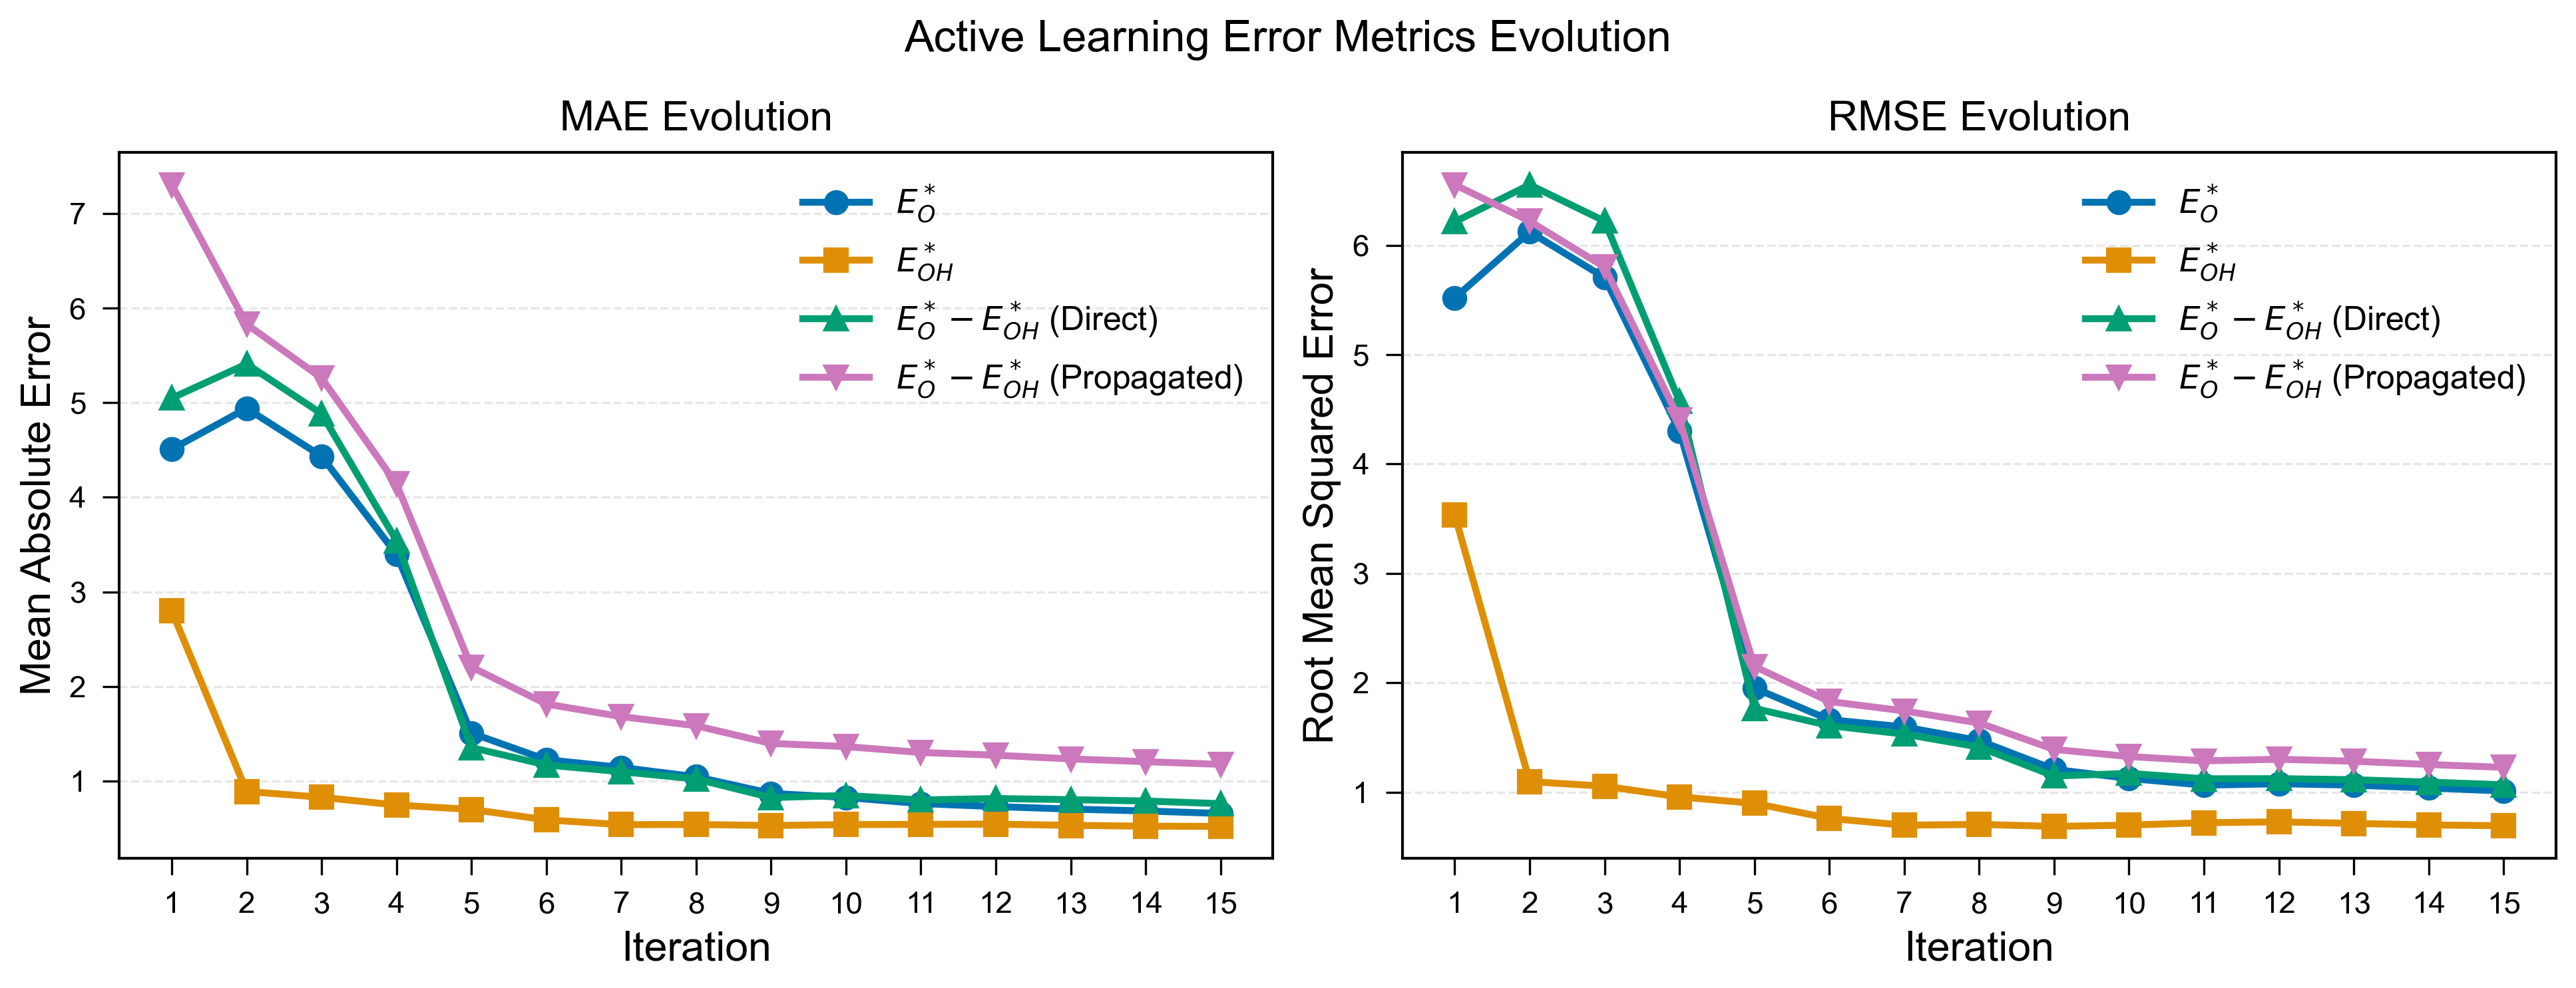

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# Font configuration
font_path = '/nas_3/active/minhee2043/font/'
for font in fm.findSystemFonts(font_path):
    fm.fontManager.addfont(font)

# Plot configuration
config = {
    'font.family': 'Arial',
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.titlepad': 8,
    'axes.linewidth': 1.0,
    'axes.labelsize': 11,
    'legend.frameon': False,
    'legend.fontsize': 9,
    'lines.linewidth': 1.0,
    'lines.markersize': 3,
    'xtick.major.size': 6,
    'xtick.major.pad': 6,
    'xtick.labelsize': 12,
    'ytick.major.size': 6,
    'ytick.major.pad': 6,
    'ytick.labelsize': 12,
    'figure.dpi': 300,
}

plt.rcParams.update(config)

# Read the CSV file
df = pd.read_csv('../1.MAE_plot/gpr_cumulative_results_total.csv')

# Create iteration numbers
iterations = np.arange(1, len(df) + 1)

# Create figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Active Learning Error Metrics Evolution', fontsize=16, fontweight='bold')

# Nature Communications-friendly color scheme
# Based on Nature journal guidelines and colorblind-accessible palettes
colors = {
    'O': '#0173B2',           # Blue - professional and accessible
    'OH': '#DE8F05',          # Orange - warm contrast
    'target': '#029E73',      # Teal/Green - distinct and clear
    'propagated': '#CC78BC'   # Purple - softer alternative to red
}

# Plot 1: MAE Evolution
ax1.plot(iterations, df['MAE_O'], 'o-', color=colors['O'], 
         label=r'$E_O^*$', linewidth=2.5, markersize=8)
ax1.plot(iterations, df['MAE_OH'], 's-', color=colors['OH'], 
         label=r'$E_{OH}^*$', linewidth=2.5, markersize=8)
ax1.plot(iterations, df['MAE_target_direct'], '^-', color=colors['target'], 
         label=r'$E_O^*-E_{OH}^*$ (Direct)', linewidth=2.5, markersize=8)
ax1.plot(iterations, df['MAE_target_propagated'], 'v-', color=colors['propagated'], 
         label=r'$E_O^*-E_{OH}^*$ (Propagated)', linewidth=2.5, markersize=8)

ax1.set_xlabel('Iteration', fontsize=15)
ax1.set_ylabel('Mean Absolute Error', fontsize=15)
ax1.set_title('MAE Evolution', fontsize=15)
ax1.legend(loc='upper right', fontsize=12, framealpha=0.9)
ax1.grid(True, alpha=0.3, linestyle='--', axis='y')
ax1.set_xticks(iterations)
ax1.tick_params(labelsize=11)

# Plot 2: RMSE Evolution
ax2.plot(iterations, df['RMSE_O'], 'o-', color=colors['O'], 
         label=r'$E_O^*$', linewidth=2.5, markersize=8)
ax2.plot(iterations, df['RMSE_OH'], 's-', color=colors['OH'], 
         label=r'$E_{OH}^*$', linewidth=2.5, markersize=8)
ax2.plot(iterations, df['RMSE_target_direct'], '^-', color=colors['target'], 
         label=r'$E_O^*-E_{OH}^*$ (Direct)', linewidth=2.5, markersize=8)
ax2.plot(iterations, df['RMSE_target_propagated'], 'v-', color=colors['propagated'], 
         label=r'$E_O^*-E_{OH}^*$ (Propagated)', linewidth=2.5, markersize=8)

ax2.set_xlabel('Iteration', fontsize=15)
ax2.set_ylabel('Root Mean Squared Error', fontsize=15)
ax2.set_title('RMSE Evolution', fontsize=15)
ax2.legend(loc='upper right', fontsize=12, framealpha=0.9)
ax2.grid(True, alpha=0.3, linestyle='--', axis='y')
ax2.set_xticks(iterations)
ax2.tick_params(labelsize=11)

plt.tight_layout()
plt.savefig('mae_rmse_evolution.png', dpi=300, bbox_inches='tight')
print("Plot saved as 'mae_rmse_evolution.png'")
print(f"\nDataset summary:")
print(f"Total iterations: {len(df)}")
print(f"Training samples: {df['n_train_O'].min()} → {df['n_train_O'].max()}")
print(f"MAE O improvement: {df['MAE_O'].iloc[0]:.3f} → {df['MAE_O'].iloc[-1]:.3f}")
print(f"MAE OH improvement: {df['MAE_OH'].iloc[0]:.3f} → {df['MAE_OH'].iloc[-1]:.3f}")
print(f"MAE Target improvement: {df['MAE_target_direct'].iloc[0]:.3f} → {df['MAE_target_direct'].iloc[-1]:.3f}")
plt.show()